In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int
from waymo_agent.osmnx.post_process_enrichment import *

In [5]:
config = EnvConfig()

In [6]:
env = RideShareEnv(config=config)

Assigned lambda values to nodes. Total lambda: 2.2225 (target: 2.3460)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [7]:
s, info = env.reset()

In [13]:
from waymo_agent.data_classes.customer import CustomerDF, CustomerDFGenator

# size = 10_000
# bias = np.random.normal(loc=0, scale=2, size=size)
# temperature = np.random.uniform(low=1.2, high=2.5, size=size)
# cust_df = CustomerDF({"cust_id": np.arange(size), "bias": bias, "temperature": temperature})

In [160]:
cust = CustomerDFGenator.generate()

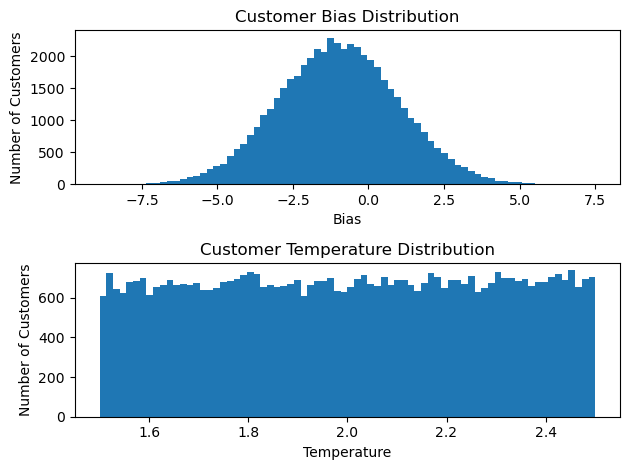

In [161]:
fig, ax = plt.subplots(2)
ax[0].hist(cust.bias, bins="rice")
ax[0].set_title("Customer Bias Distribution")
ax[0].set_xlabel("Bias")
ax[0].set_ylabel("Number of Customers")

ax[1].hist(cust.temperature, bins="rice")
ax[1].set_title("Customer Temperature Distribution")
ax[1].set_xlabel("Temperature")
ax[1].set_ylabel("Number of Customers")
fig.tight_layout()

In [162]:
test_size = 10_000
requests_df = pd.DataFrame(
    {"est_cost": np.random.uniform(5, 50, size=test_size), "cust_id": np.random.choice(cust.cust_id, size=test_size)}
)
prices = requests_df["est_cost"] * 1.6

In [163]:
sd_ratio = 0.3

In [164]:
from waymo_agent.data_classes.customer import price_acceptance_probability


prob, z = price_acceptance_probability(cust_df, requests_df, prices.values, sd_ratio, config)

In [165]:
prob.mean()

np.float64(0.5267197872117302)

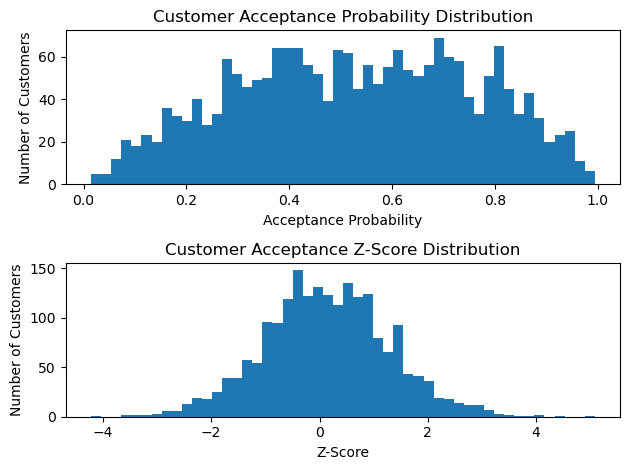

In [166]:
fig, ax = plt.subplots(2)
ax[0].hist(prob, bins=50)
ax[0].set_title("Customer Acceptance Probability Distribution")
ax[0].set_xlabel("Acceptance Probability")
ax[0].set_ylabel("Number of Customers")

ax[1].hist(z, bins=50)
ax[1].set_title("Customer Acceptance Z-Score Distribution")
ax[1].set_xlabel("Z-Score")
ax[1].set_ylabel("Number of Customers")

fig.tight_layout()
plt.show()

In [167]:
env.longest_distance / 1628.34  # miles

9.398360690804834

In [168]:
inspect_graph(env.G)

Graph has 782 nodes and 2746 edges.
Sample node -sample_node_id=42436489- attributes: {'y': 40.7688122, 'x': -73.9583845, 'highway': 'traffic_signals', 'street_count': 4, 'lambda': 0.00149, 'x_centered': 0.02125, 'y_centered': 0.013829, 'x_norm': 0.332562, 'y_norm': 0.216417}

Sample edge attributes: {'osmid': 993383311, 'highway': 'primary_link', 'oneway': False, 'reversed': False, 'length': 23.534023513894653, 'maxspeed': 30.0, 'travel_time_minutes': 0.0471}

cls.edge_length_unit='meters', cls.speed_unit='km/h', cls.time_unit='minutes'


In [169]:
env.longest_distance * config.operating_cost_per_km / 1000

15.303726647265142

In [171]:
from waymo_agent.data_classes.customer import CustomerDFGenator


CustomerDFGenator.save()

Saved CustomerDF to /Users/Akseldkw/coding/Columbia/RL-Project/data_sim/customers.parquet
